In [13]:
import h5py
import pyvista as pv
import numpy as np

dft_path = '/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_ref_mean.h5'

# 1. Load the data
with h5py.File(dft_path, 'r') as file:
    dft_d = file['density'][:]

# Let's print the actual range of your data so you know what you're working with
data_min = dft_d.min()
data_max = dft_d.max()
print(f"Density range: {data_min} to {data_max}")

# 2. Create the grid
grid = pv.ImageData()
grid.dimensions = dft_d.shape
grid.point_data["Density"] = dft_d.flatten(order="F")

# 3. Dynamically set the isovalue 
# (Let's start at 10% of the maximum value)
isovalue_dft = data_max * 0.60 
print(f"Extracting isosurface at: {isovalue_dft}")

isosurface = grid.contour([isovalue_dft])

# 4. Safety check and Plot
if isosurface.n_points == 0:
    print("Uh oh! The isosurface is still empty. Try adjusting the multiplier (e.g., 0.50 instead of 0.10).")
else:
    plotter = pv.Plotter()
    plotter.add_mesh(isosurface, color='cyan', opacity=0.75, smooth_shading=True)
    plotter.add_axes()
    plotter.show()
import pyvista as pv
import numpy as np

dft_path = '/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0000655360.h5'

# 1. Load the data
with h5py.File(dft_path, 'r') as file:
    dft_d = file['density'][:]

# Let's print the actual range of your data so you know what you're working with
data_min = dft_d.min()
data_max = dft_d.max()
print(f"Density range: {data_min} to {data_max}")

# 2. Create the grid
grid = pv.ImageData()
grid.dimensions = dft_d.shape
grid.point_data["Density"] = dft_d.flatten(order="F")

# 3. Dynamically set the isovalue 
# (Let's start at 10% of the maximum value)
isovalue =isovalue_dft
print(f"Extracting isosurface at: {isovalue}")

isosurface = grid.contour([isovalue])

# 4. Safety check and Plot
if isosurface.n_points == 0:
    print("Uh oh! The isosurface is still empty. Try adjusting the multiplier (e.g., 0.50 instead of 0.10).")
else:
    plotter = pv.Plotter()
    plotter.add_mesh(isosurface, color='cyan', opacity=0.75, smooth_shading=True)
    plotter.add_axes()
    plotter.show()

Density range: 3.6275576031397687e-06 to 0.00010828858330136255
Extracting isosurface at: 6.497314998081752e-05


2026-03-26 09:06:05.751 (   3.921s) [    7F8F80BF0B80]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=


Widget(value='<iframe src="/user/kberard/perlmutter-shared-node-gpu/proxy/39405/index.html?ui=P_0x7f8bfacef260…

Density range: 0.0 to 0.00017852783203124996
Extracting isosurface at: 6.497314998081752e-05


Widget(value='<iframe src="/user/kberard/perlmutter-shared-node-gpu/proxy/39405/index.html?ui=P_0x7f8bf1baeb70…

In [14]:
#Transform density
def transform(density,density_ref,transform_type):
    dens = density
    dref  = density_ref
    ttype = transform_type
    if ttype=='value':
        dtrans = density
    elif ttype=='sqrt':
        dtrans = np.sqrt(np.abs(density))
    elif ttype=='log':
        dtrans  = np.log(np.abs(density))
    elif ttype=='residual_noise':
        dval  = dref
        dsqrt = np.sqrt(np.abs(dref))
        dtrans = (dens-dval)/dsqrt
    else:
        raise RuntimeError('bad transform type')
    return dtrans


def inverse_transform(density_trans,density_ref,transform_type):
    dref   = density_ref
    ttype  = transform_type
    dtrans = density_trans
    if ttype=='value':
        density = dtrans
    elif ttype=='sqrt':
        density = dtrans**2
    elif ttype=='log':
        density = np.log(np.abs(dtrans))
    elif ttype=='residual_noise':
        dval  = dref
        dsqrt = np.sqrt(np.abs(dref))
        density = dval + dsqrt*dtrans
    else:
        raise RuntimeError('bad transform type')
    return density


In [15]:
with h5py.File('/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0000655360.h5', 'r') as file:
    #print("Keys: %s" % file.keys())
    test_d = file['density'][:]
"""with h5py.File('/pscratch/sd/k/kberard/SCGSR/EDDA/Diamond/Data_Gen/plot_data/Image_Den_Plot_allM/density_tot_vmc_mean_0000081920.h5', 'r') as file:
    #print("Keys: %s" % file.keys())
    test_d = file['density'][:]"""
    
dft_path ='/global/u2/k/kberard/SCGSR/Research/Diamond/Data/density_tot_ref.h5'
with h5py.File(dft_path, 'r') as file:
    dft_d = file['density'][:]

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf 
model = tf.keras.models.load_model('../Density_Models/UNET_3D_Models/residual_denoiser_40M_Blob.keras')
# -----------------------------------------------------------
# 1. PREPARE DATA FOR MODEL
# -----------------------------------------------------------
# Reshape arrays to (1, H, W, D, 1) for the model
# We need 'dft_d' because the residual transform relies on it.
input_reshaped = test_d[np.newaxis, ..., np.newaxis]
dft_reshaped   = dft_d[np.newaxis, ..., np.newaxis]

# -----------------------------------------------------------
# 2. TRANSFORM INPUT (Forward Pass)
# -----------------------------------------------------------
# Convert raw noisy density -> "How far is this from DFT?"
# Uses the 'transform' function we defined earlier
input_residual = transform(input_reshaped, dft_reshaped, 'residual_noise')

# -----------------------------------------------------------
# 3. PREDICT
# -----------------------------------------------------------
# The model predicts the "Corrected Residual"
pred_residual = model.predict(input_residual)

# -----------------------------------------------------------
# 4. INVERSE TRANSFORM (Recover Density)
# -----------------------------------------------------------
# Convert "Corrected Residual" back to "Physical Density"
# Logic: Density = DFT + (Residual * sqrt(DFT))
denoised_raw = inverse_transform(pred_residual, dft_reshaped, 'residual_noise')

# Squeeze back to 3D shape (116, 116, 72)
denoised = denoised_raw[0, ..., 0]



1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 525ms/step


In [17]:
#np.save('/pscratch/sd/k/kberard/SCGSR/EDDA/Diamond/Data_Gen/plot_data/Image_Den_Plot_allM/density_sample_81920_UNET_3D.npy', denoised)

In [18]:

dft_d = denoised

# Let's print the actual range of your data so you know what you're working with
data_min = dft_d.min()
data_max = dft_d.max()
print(f"Density range: {data_min} to {data_max}")

# 2. Create the grid
grid = pv.ImageData()
grid.dimensions = dft_d.shape
grid.point_data["Density"] = dft_d.flatten(order="F")

# 3. Dynamically set the isovalue 
# (Let's start at 10% of the maximum value)
isovalue =isovalue_dft
print(f"Extracting isosurface at: {isovalue}")

isosurface = grid.contour([isovalue])

# 4. Safety check and Plot
if isosurface.n_points == 0:
    print("Uh oh! The isosurface is still empty. Try adjusting the multiplier (e.g., 0.50 instead of 0.10).")
else:
    plotter = pv.Plotter()
    plotter.add_mesh(isosurface, color='cyan', opacity=0.75, smooth_shading=True)
    plotter.add_axes()
    plotter.show()

Density range: 2.933451925068582e-06 to 0.00011045777892745691
Extracting isosurface at: 6.497314998081752e-05


Widget(value='<iframe src="/user/kberard/perlmutter-shared-node-gpu/proxy/39405/index.html?ui=P_0x7f8e3020d9a0…

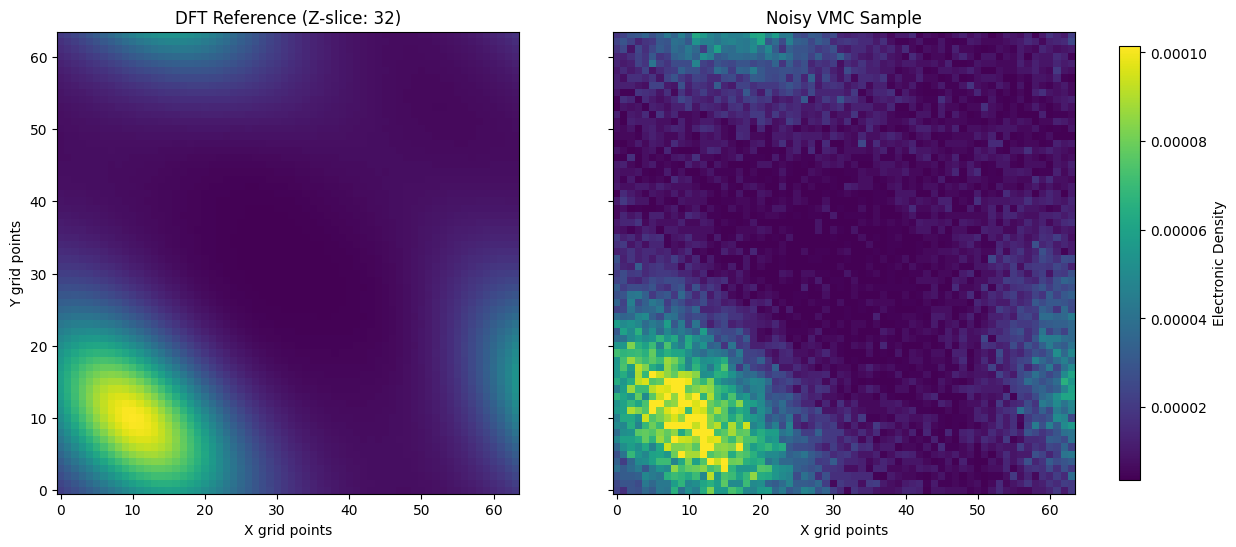

In [1]:
import h5py
import matplotlib.pyplot as plt
import numpy as np

# File paths
dft_path = '/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_ref_mean.h5'
vmc_path = '/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0000655360.h5'

# 1. Load both datasets
with h5py.File(dft_path, 'r') as file:
    dft_data = file['density'][:]
    
with h5py.File(vmc_path, 'r') as file:
    vmc_data = file['density'][:]

# 2. Extract the exact same 2D slice (Middle of the Z-axis)
z_index = dft_data.shape[2] // 2
slice_dft = dft_data[:, :, z_index]
slice_vmc = vmc_data[:, :, z_index]

# 3. Lock the color scale to the DFT reference for a 1:1 comparison
# (Alternatively, you could use the absolute min/max across both arrays, 
# but tying it to the reference usually handles noise spikes better)
vmin_shared = slice_dft.min()
vmax_shared = slice_dft.max()

# 4. Set up the side-by-side plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plot DFT Reference
im_dft = axes[0].imshow(slice_dft.T, cmap='viridis', origin='lower', 
                        vmin=vmin_shared, vmax=vmax_shared)
axes[0].set_title(f'DFT Reference (Z-slice: {z_index})')
axes[0].set_xlabel('X grid points')
axes[0].set_ylabel('Y grid points')

# Plot VMC Sample
im_vmc = axes[1].imshow(slice_vmc.T, cmap='viridis', origin='lower', 
                        vmin=vmin_shared, vmax=vmax_shared)
axes[1].set_title('Noisy VMC Sample')
axes[1].set_xlabel('X grid points')

# 5. Add a single colorbar that applies to both plots
cbar = fig.colorbar(im_dft, ax=axes.ravel().tolist(), fraction=0.02, pad=0.04)
cbar.set_label('Electronic Density')

plt.show()